In [3]:
import pandas as pd

data = [
    {"timestamp": "2026-08-01 10:01:00", "level": "INFO", "source": "api", "duration_ms": "120", "bytes": 1024, "msg": "start"},
    {"timestamp": "2026-08-01 10:01:05", "level": "ERROR", "source": "db", "duration_ms": "bad", "bytes": 2048, "msg": "timeout"},
    {"timestamp": "2026-08-01 10:01:09", "level": "INFO", "source": "api", "duration_ms": "95", "bytes": None, "msg": "ok"},
]

logs_df = pd.DataFrame(data)
print(logs_df)

print(logs_df.shape)
print(logs_df.columns)
print(logs_df.dtypes)
print(logs_df.isna().sum())

             timestamp  level source duration_ms   bytes      msg
0  2026-08-01 10:01:00   INFO    api         120  1024.0    start
1  2026-08-01 10:01:05  ERROR     db         bad  2048.0  timeout
2  2026-08-01 10:01:09   INFO    api          95     NaN       ok
(3, 6)
Index(['timestamp', 'level', 'source', 'duration_ms', 'bytes', 'msg'], dtype='object')
timestamp       object
level           object
source          object
duration_ms     object
bytes          float64
msg             object
dtype: object
timestamp      0
level          0
source         0
duration_ms    0
bytes          1
msg            0
dtype: int64


In [4]:
logs_df["timestamp"] = pd.to_datetime(
    logs_df["timestamp"],
    errors="coerce",
)

logs_df["duration_ms"] = pd.to_numeric(
    logs_df["duration_ms"],
    errors="coerce",
)

print(logs_df)
print(logs_df.dtypes)
print(logs_df.isna().sum())

            timestamp  level source  duration_ms   bytes      msg
0 2026-08-01 10:01:00   INFO    api        120.0  1024.0    start
1 2026-08-01 10:01:05  ERROR     db          NaN  2048.0  timeout
2 2026-08-01 10:01:09   INFO    api         95.0     NaN       ok
timestamp      datetime64[ns]
level                  object
source                 object
duration_ms           float64
bytes                 float64
msg                    object
dtype: object
timestamp      0
level          0
source         0
duration_ms    1
bytes          1
msg            0
dtype: int64


In [14]:
clean_df = logs_df.copy()

duration_median = clean_df["duration_ms"].median()

clean_df["duration_ms"] = clean_df["duration_ms"].fillna(
    duration_median
)

clean_df["bytes"] = clean_df["bytes"].fillna(0)

display(clean_df)
display(clean_df.dtypes)
display(clean_df.isna().sum())

,timestamp,level,source,duration_ms,bytes,msg
0,2026-08-01 10:01:00,INFO,api,120.0,1024.0,start
1,2026-08-01 10:01:05,ERROR,db,107.5,2048.0,timeout
2,2026-08-01 10:01:09,INFO,api,95.0,0.0,ok


timestamp      datetime64[ns]
level                  object
source                 object
duration_ms           float64
bytes                 float64
msg                    object
dtype: object

timestamp      0
level          0
source         0
duration_ms    0
bytes          0
msg            0
dtype: int64

In [16]:
error_logs = clean_df[clean_df["level"] == "ERROR"]

display(error_logs)

slow_logs = clean_df[clean_df["duration_ms"] > 100]

display(slow_logs)

slow_errors = clean_df[(clean_df["level"] == "ERROR") & (clean_df["duration_ms"] > 100)]

display(slow_errors)

,timestamp,level,source,duration_ms,bytes,msg
1,2026-08-01 10:01:05,ERROR,db,107.5,2048.0,timeout


,timestamp,level,source,duration_ms,bytes,msg
0,2026-08-01 10:01:00,INFO,api,120.0,1024.0,start
1,2026-08-01 10:01:05,ERROR,db,107.5,2048.0,timeout


,timestamp,level,source,duration_ms,bytes,msg
1,2026-08-01 10:01:05,ERROR,db,107.5,2048.0,timeout


In [17]:
error_summary = clean_df.loc[
    clean_df["level"] == "ERROR",
    ["timestamp", "source", "duration_ms", "msg"]
]

display(error_summary)

first_rows = clean_df.iloc[:2, :3]

display(first_rows)

,timestamp,source,duration_ms,msg
1,2026-08-01 10:01:05,db,107.5,timeout


,timestamp,level,source
0,2026-08-01 10:01:00,INFO,api
1,2026-08-01 10:01:05,ERROR,db


In [19]:
api_summary = clean_df.loc[
    clean_df["source"] == "api",
    ["timestamp", "duration_ms","msg"]
].reset_index(drop=True)

display(api_summary)

,timestamp,duration_ms,msg
0,2026-08-01 10:01:00,120.0,start
1,2026-08-01 10:01:09,95.0,ok


In [20]:
source_summary = clean_df.groupby("source").agg(
    log_count=("source", "size"),
    avg_duration_ms=("duration_ms", "mean"),
    total_bytes=("bytes", "sum"),
)

display(source_summary)

,log_count,avg_duration_ms,total_bytes
source,,,
api,2,107.5,1024.0
db,1,107.5,2048.0


In [21]:
observed_summary = logs_df.groupby("source").agg(
    log_count=("source", "size"),
    valid_duration_count=("duration_ms", "count"),
    avg_duration_ms=("duration_ms", "mean"),
)

display(observed_summary)

,log_count,valid_duration_count,avg_duration_ms
source,,,
api,2,2,107.5
db,1,0,NaN


In [23]:
observed_summary["duration_valid_pct"] = (
    observed_summary["duration_valid_rate"] * 100
).round(1)

display(observed_summary)

,log_count,valid_duration_count,avg_duration_ms,duration_valid_rate,duration_valid_pct
source,,,,,
api,2,2,107.5,1.0,100.0
db,1,0,NaN,0.0,0.0


In [24]:
level_source_table = pd.pivot_table(
    clean_df,
    index="source",
    columns="level",
    values="msg",
    aggfunc="count",
    fill_value=0,
)

display(level_source_table)

level,ERROR,INFO
source,,
api,0,2
db,1,0


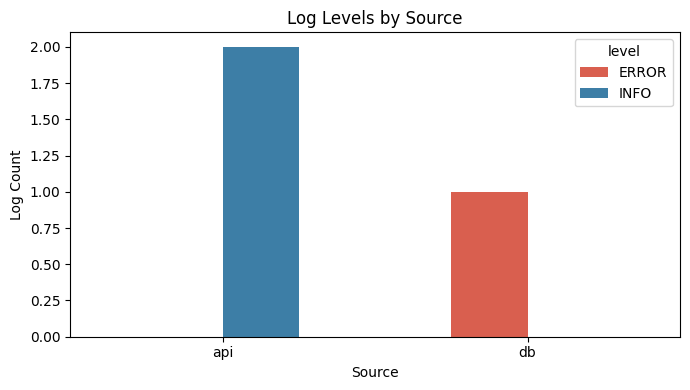

In [ ]:
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

ax = level_source_table.plot(
    kind="bar",
    figsize=(7 ,4),
    color=["#d95f4f", "#3d7ea6"],
)

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.title("Log Levels by Source")
plt.xlabel("Source")
plt.ylabel("Log Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()